# Part 2: Genres and communities and plotting

* *Write about genres and modularity.*

In order to extract the genre information from all the artists pages, I started by loading the network from Github. Each node contains the name of the artist and its corresponding page content.

In [22]:
import urllib
import networkx as nx
import io

# Load the network
url = "https://raw.githubusercontent.com/denisababeii/socialgraphs_assignment2/refs/heads/denisa/network.graphml"
    
try:
    with urllib.request.urlopen(url) as response:
        data = response.read()
        
    network = nx.read_graphml(io.BytesIO(data))
    print(f"✓ Network loaded successfully!")
    print(f"  Nodes: {network.number_of_nodes()}")
    print(f"  Edges: {network.number_of_edges()}")
        
except Exception as e:
    print(f"✗ Error loading network: {str(e)}")
    network = None

✓ Network loaded successfully!
  Nodes: 486
  Edges: 7655


With the help of an LLM, I defined a function to extract the genre information from each page.

In [33]:
import os
import json
import re
from collections import Counter, defaultdict
import matplotlib.pyplot as plt
import urllib.request

# Helper function to clean the genre text
def clean_genre(genre):
    # Remove reference tags like <ref>...</ref>
    genre = re.sub(r'<ref[^>]*>.*?</ref>', '', genre, flags=re.DOTALL)
    # Remove {{nowrap|...}}
    genre = re.sub(r'\{\{nowrap\|(.*?)\}\}', r'\1', genre)
    # Remove any remaining {{ }}
    genre = re.sub(r'\{\{[^}]*\}\}', '', genre)
    # Remove brackets
    genre = re.sub(r'[\[\]]', '', genre)
    # Clean whitespace
    genre = ' '.join(genre.split())
    # Change to lowercase
    genre = genre.lower().strip()
    
    # Map various rock variants to single genre
    rock_variants = {
        "rock'n'roll": "rock and roll",
        "rock & roll": "rock and roll",
        "rock 'n' roll": "rock and roll",
        "rock n roll": "rock and roll",
        "rock-and-roll": "rock and roll"
    }
    
    if genre in rock_variants:
        return rock_variants[genre]
    
    return genre

# Extract genres list from the wikipedia pages
def extract_genres(content):
    # Parse the JSON structure
    data = json.loads(content)
    
    # Navigate to the wikitext content
    pages = data.get('query', {}).get('pages', {})
    if not pages:
        return []
    
    # Get the page
    page_id = list(pages.keys())[0]
    wikitext = pages[page_id].get('revisions', [{}])[0].get('slots', {}).get('main', {}).get('*', '')
    
    if not wikitext:
        return []
    
    # Extract the Infobox musical artist section
    infobox_pattern = r'\{\{Infobox musical artist(.*?)\n\}\}'
    infobox_match = re.search(infobox_pattern, wikitext, re.DOTALL | re.IGNORECASE)
    
    if not infobox_match:
        return []
    
    infobox_content = infobox_match.group(1)
    
    # Extract genre field
    # Look for | genre = followed by content until the next | field
    genre_pattern = r'\|\s*genre\s*=\s*(.*?)(?=\n\||\n\}\})'
    genre_match = re.search(genre_pattern, infobox_content, re.DOTALL | re.IGNORECASE)
    
    if not genre_match:
        return []

    genre_content = genre_match.group(1).strip()
    
    # Parse genres - they can be in various formats
    genres = []
    
    # Remove {{flatlist| and }} wrappers
    genre_content = re.sub(r'\{\{flatlist\|', '', genre_content, flags=re.IGNORECASE)
    genre_content = re.sub(r'\}\}', '', genre_content)
    
    # Remove wiki formatting like [[Genre]] or [[Genre|display text]]
    # Pattern: [[link]] or [[link|text]]
    wiki_links = re.findall(r'\[\[([^\]|]+)(?:\|[^\]]+)?\]\]', genre_content)
    
    if wiki_links:
        # If we found wiki links, use those
        genres = wiki_links
    else:
        # Otherwise, split by common separators
        # Remove any remaining markup
        genre_content = re.sub(r'<[^>]+>', '', genre_content)
        genre_content = re.sub(r'\*\s*', '', genre_content)
        
        # Split by newlines, commas or bullets
        genre_list = re.split(r'[\n,•]', genre_content)
        genres = [g.strip() for g in genre_list if g.strip()]
    
    # Clean genres
    cleaned_genres = []
    for genre in genres:
        if genre:
            cleaned_genre = clean_genre(genre)
            if cleaned_genre != 'allmusic': # Remove allmusic (discovered during testing)
                cleaned_genres.append(cleaned_genre)
    
    return cleaned_genres

I extracted the genres from each node and added them as a node attribute.

In [34]:
artist_genres = []

for n in network.nodes():
    # Add genres as a list attribute
    genres = extract_genres(network.nodes[n]['content'])
    artist_genres.append(genres)
    network.nodes[n]['genres'] = genres

With the help of an LLM, I created a function that generates statistics for genres. The function returns:
1. The number of nodes with genres
2. The average number of genres per node
3. The total number of distinct genres
4. The top 15 genres

In [ ]:
# Generate statistics for the nodes with genres
def generate_statistics(nodes_with_genres):
    # 1. Number of nodes with genres
    num_artists_with_genres = len(nodes_with_genres)
    print(f"\n1. Number of artists with genres: {num_artists_with_genres}")
    
    # 2. Average number of genres per node
    total_genres = sum(len(network.nodes[node]['genres']) for node in nodes_with_genres)
    avg_genres = total_genres / num_artists_with_genres if num_artists_with_genres > 0 else 0
    print(f"2. Average number of genres per artist: {avg_genres:.2f}")
    
    # 3. Total number of distinct genres
    all_genres = set()
    for node in nodes_with_genres:
        genres = network.nodes[node]['genres']
        all_genres.update(genres)
    num_distinct_genres = len(all_genres)
    print(f"3. Total number of distinct genres: {num_distinct_genres}")
    
    # 4. Top 15 genres histogram
    genre_counter = Counter()
    for node in nodes_with_genres:
        genres = network.nodes[node]['genres']
        genre_counter.update(genres)
    
    top_15 = genre_counter.most_common(15)
    
    print(f"\n4. Top 15 genres:")
    for i, (genre, count) in enumerate(top_15, 1):
        print(f"   {i:2d}. {genre:30s} - {count:3d} artists")
    
    # Create histogram
    if top_15:
        genres_list, counts = zip(*top_15)
        
        plt.figure(figsize=(14, 8))
        bars = plt.barh(range(len(genres_list)), counts, color='steelblue')
        plt.yticks(range(len(genres_list)), genres_list)
        plt.xlabel('Number of Artists', fontsize=12)
        plt.ylabel('Genre', fontsize=12)
        plt.title('Top 15 Genres by Artist Count', fontsize=14, fontweight='bold')
        plt.gca().invert_yaxis()  # Highest at top
        
        # Add count labels on bars
        for i, (bar, count) in enumerate(zip(bars, counts)):
            plt.text(count + 0.5, i, str(count), va='center', fontsize=10)
        
        plt.tight_layout()
        plt.show()
    
    return {
        'num_artists_with_genres': num_artists_with_genres,
        'avg_genres_per_artist': avg_genres,
        'num_distinct_genres': num_distinct_genres,
        'top_15_genres': top_15
    }

I generate statistics for the nodes which I have extracted genres from.


1. Number of artists with genres: 148
2. Average number of genres per artist: 3.84
3. Total number of distinct genres: 152

4. Top 15 genres:
    1. hard rock                      -  33 artists
    2. rock music                     -  32 artists
    3. pop rock                       -  30 artists
    4. pop music                      -  23 artists
    5. alternative rock               -  22 artists
    6. blues rock                     -  22 artists
    7. soft rock                      -  20 artists
    8. art rock                       -  13 artists
    9. heavy metal music              -  13 artists
   10. rock and roll                  -  13 artists
   11. country rock                   -  13 artists
   12. folk rock                      -  13 artists
   13. southern rock                  -  11 artists
   14. indie rock                     -  10 artists
   15. new wave music                 -  10 artists


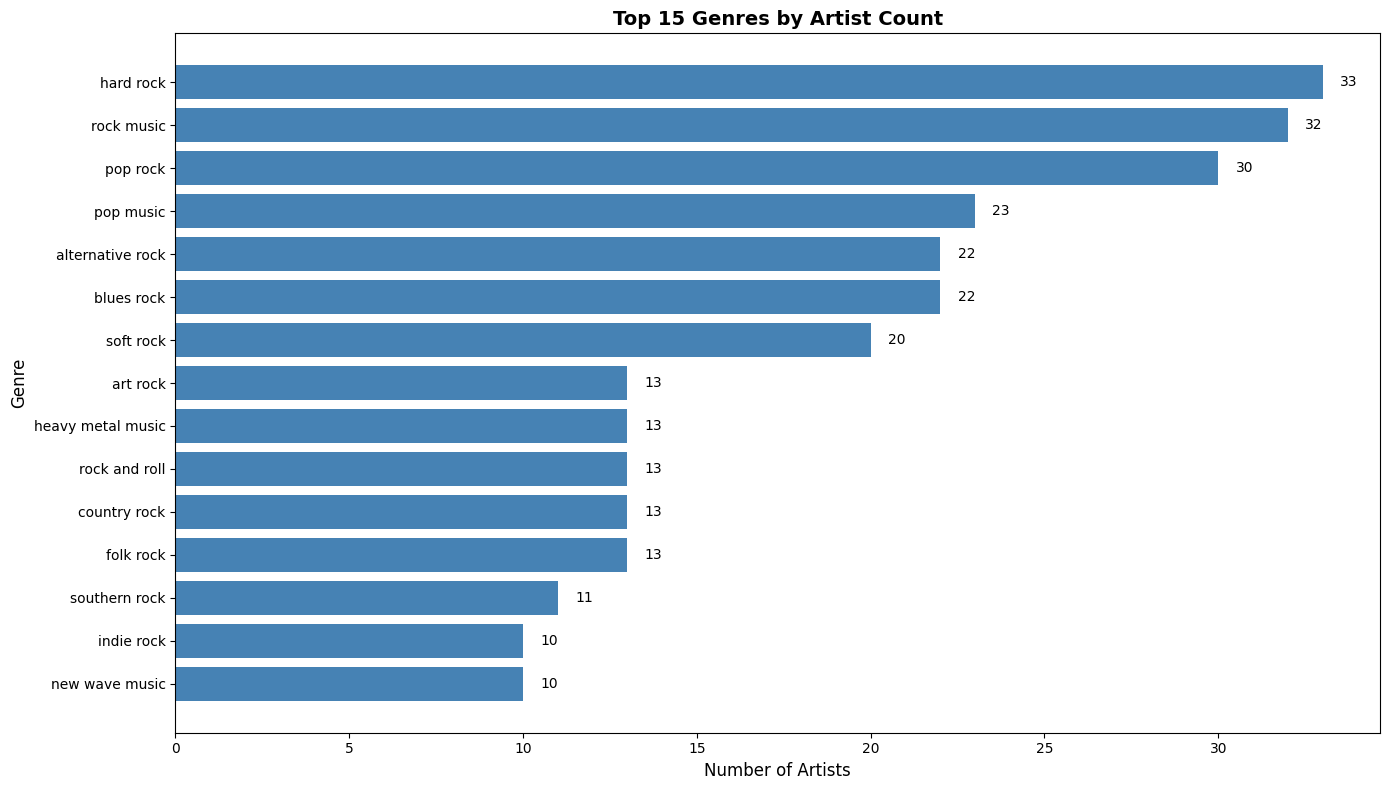

In [36]:
nodes_with_genres = [n for n in network.nodes() if network.nodes[n]['genres']]
stats = generate_statistics(nodes_with_genres)

As expected, the genres are mostly subsets of the rock genre. It can also be observed that Wikipedia considers subgenres of rock but also the broad genres like 'rock music' or 'pop music' when defining the artists. Also an interesting mention is that 'pop music' also appears in the list, so a lot of the artists are actually blending rock and pop music.

For computing modularity, I continue to work with a subnetwork of nodes containing genre information.

In [37]:
subnetwork = network.subgraph(nodes_with_genres)

According to the [Network Science book - Section 9.4](https://networksciencebook.com/chapter/9#modularity:~:text=Section%209.4-,Modularity,-In%20a%20randomly), modularity is defined as a measure of a partition's quality, helping to decide if a community partition is better than another one.

TBD: ADD MORE ABOUT MODULARITY

* *Detect the communities, discuss the value of modularity in comparison to the genres.*

* *Calculate the matrix D and discuss your findings.*

* *Plot the communities and comment on your results.*